In [1]:
import os
import json
import pandas as pd


### Combine data across annotators

In [2]:
dir = "annotations"
all_annotations = []

# Iterate through all files in the directory
for file in os.listdir(dir):
    if file.endswith('.jsonl'):
        with open(os.path.join(dir, file), 'r') as f:
            for line in f:
                try:
                    # Parse each line as a JSON object
                    annotation = json.loads(line)
                    all_annotations.append(annotation)
                except json.JSONDecodeError:
                    print(f"Error parsing line: {line}")

df = pd.DataFrame(all_annotations)

### Add sample id

In [3]:
def create_sample_id(row):
    return f"{row['original_name']}_{row['revised_name']}"

df["sample_id"] = df.apply(create_sample_id, axis=1)

In [4]:
df.head()

,annotator,original_name,revised_name,score,label,feedback,timestamp,sample_id
0,Kylie,anthropic,seed1_ep1_optimal,0.51,leaning yes,Some of the prioritizations are overly specific.,1.775769e+09,anthropic_seed1_ep1_optimal
1,Kylie,anthropic,seed1_ep1_set1,-1.00,no,,1.775769e+09,anthropic_seed1_ep1_set1
2,Kylie,anthropic,seed1_ep1_set2,0.93,yes,Rule 54 too specific.,1.775769e+09,anthropic_seed1_ep1_set2
3,Kylie,fineweb,optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,0.69,yes,very different but same vibes,1.775769e+09,fineweb_optimal_rule_set_v1_0126yes1smrc-20362...
4,Kylie,fineweb,optimal_rule_set_v1_yes1smrc-153317-0-ep10,-0.18,unsure,,1.775769e+09,fineweb_optimal_rule_set_v1_yes1smrc-153317-0-...


### Add bucketed labels

In [5]:
BUCKET_MAP_MORE_UNSURE = {"yes": "yes", "leaning yes": "unsure", "unsure": "unsure", "leaning no": "unsure", "no": "no"}
df["label_bucket_more_unsure"] = df["label"].map(BUCKET_MAP_MORE_UNSURE)
df.head()

,annotator,original_name,revised_name,score,label,feedback,timestamp,sample_id,label_bucket_more_unsure
0,Kylie,anthropic,seed1_ep1_optimal,0.51,leaning yes,Some of the prioritizations are overly specific.,1.775769e+09,anthropic_seed1_ep1_optimal,unsure
1,Kylie,anthropic,seed1_ep1_set1,-1.00,no,,1.775769e+09,anthropic_seed1_ep1_set1,no
2,Kylie,anthropic,seed1_ep1_set2,0.93,yes,Rule 54 too specific.,1.775769e+09,anthropic_seed1_ep1_set2,yes
3,Kylie,fineweb,optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,0.69,yes,very different but same vibes,1.775769e+09,fineweb_optimal_rule_set_v1_0126yes1smrc-20362...,yes
4,Kylie,fineweb,optimal_rule_set_v1_yes1smrc-153317-0-ep10,-0.18,unsure,,1.775769e+09,fineweb_optimal_rule_set_v1_yes1smrc-153317-0-...,unsure


In [6]:
BUCKET_MAP_LESS_UNSURE = {"yes": "yes", "leaning yes": "yes", "unsure": "unsure", "leaning no": "no", "no": "no"}
df["label_bucket_less_unsure"] = df["label"].map(BUCKET_MAP_LESS_UNSURE)
df.head()

,annotator,original_name,revised_name,score,label,feedback,timestamp,sample_id,label_bucket_more_unsure,label_bucket_less_unsure
0,Kylie,anthropic,seed1_ep1_optimal,0.51,leaning yes,Some of the prioritizations are overly specific.,1.775769e+09,anthropic_seed1_ep1_optimal,unsure,yes
1,Kylie,anthropic,seed1_ep1_set1,-1.00,no,,1.775769e+09,anthropic_seed1_ep1_set1,no,no
2,Kylie,anthropic,seed1_ep1_set2,0.93,yes,Rule 54 too specific.,1.775769e+09,anthropic_seed1_ep1_set2,yes,yes
3,Kylie,fineweb,optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,0.69,yes,very different but same vibes,1.775769e+09,fineweb_optimal_rule_set_v1_0126yes1smrc-20362...,yes,yes
4,Kylie,fineweb,optimal_rule_set_v1_yes1smrc-153317-0-ep10,-0.18,unsure,,1.775769e+09,fineweb_optimal_rule_set_v1_yes1smrc-153317-0-...,unsure,unsure


In [7]:
def label_based_on_score(row):
    if row["score"] >= 0.5:
        return "yes"
    elif row["score"] <= -0.5:
        return "no"
    else:
        return "unsure"
df["label_based_on_score"] = df.apply(label_based_on_score, axis=1)
df.head()

,annotator,original_name,revised_name,score,label,feedback,timestamp,sample_id,label_bucket_more_unsure,label_bucket_less_unsure,label_based_on_score
0,Kylie,anthropic,seed1_ep1_optimal,0.51,leaning yes,Some of the prioritizations are overly specific.,1.775769e+09,anthropic_seed1_ep1_optimal,unsure,yes,yes
1,Kylie,anthropic,seed1_ep1_set1,-1.00,no,,1.775769e+09,anthropic_seed1_ep1_set1,no,no,no
2,Kylie,anthropic,seed1_ep1_set2,0.93,yes,Rule 54 too specific.,1.775769e+09,anthropic_seed1_ep1_set2,yes,yes,yes
3,Kylie,fineweb,optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,0.69,yes,very different but same vibes,1.775769e+09,fineweb_optimal_rule_set_v1_0126yes1smrc-20362...,yes,yes,yes
4,Kylie,fineweb,optimal_rule_set_v1_yes1smrc-153317-0-ep10,-0.18,unsure,,1.775769e+09,fineweb_optimal_rule_set_v1_yes1smrc-153317-0-...,unsure,unsure,unsure


### Create pivot tables

In [8]:
df_pivot_more_unsure = df.pivot_table(
    index="sample_id",
    columns="annotator",
    values="label_bucket_more_unsure",
    aggfunc="first"   # or 'last' or custom
)
df_pivot_more_unsure.head()

annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu
sample_id,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,unsure,unsure,unsure,unsure,unsure,yes,yes,unsure
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,unsure,unsure
anthropic_seed1_ep1_set2,yes,unsure,unsure,yes,unsure,unsure,no,unsure,yes,no
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,unsure,yes,yes,yes,yes,unsure,unsure,yes,unsure
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,unsure,yes,unsure,unsure,unsure,yes,unsure,unsure,yes,yes


In [9]:
df_pivot_less_unsure = df.pivot_table(
    index="sample_id",
    columns="annotator",
    values="label_bucket_less_unsure",
    aggfunc="first"   # or 'last' or custom
)
df_pivot_less_unsure.head()

annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu
sample_id,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,no,yes,yes,yes,no,yes,yes,no
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,yes,no
anthropic_seed1_ep1_set2,yes,unsure,no,yes,yes,unsure,no,yes,yes,no
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,yes,yes,yes,yes,yes,no,no,yes,yes
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,no,yes,yes,unsure,yes,yes,no,yes,yes,yes


In [10]:
df_pivot_score = df.pivot_table(
    index="sample_id",
    columns="annotator",
    values="label_based_on_score",
    aggfunc="first"   # or 'last' or custom
)
df_pivot_score.head()

annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu
sample_id,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,no,yes,yes,yes,no,yes,yes,unsure
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,yes,no
anthropic_seed1_ep1_set2,yes,unsure,unsure,yes,unsure,unsure,no,unsure,yes,no
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,yes,yes,yes,yes,yes,unsure,unsure,yes,yes
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,no,yes,unsure,unsure,yes,yes,unsure,yes,yes,yes


### Calculate entropy

In [11]:
import math
def calculate_consensus_entropy_yes_no_unsure(data_list):
    """Two-class consensus entropy. Each 'unsure' contributes (0.5 yes, 0.5 no)."""
    if not data_list:
        return 0.0

    yes_count = data_list.count("yes") + 0.5 * data_list.count("unsure")
    no_count = data_list.count("no") + 0.5 * data_list.count("unsure")

    yes_no_total = yes_count + no_count
    if yes_no_total == 0:
        return 0.0
    probs = [yes_count / yes_no_total, no_count / yes_no_total]
    return -sum(p * math.log2(p) for p in probs if p > 0)

In [12]:
# apply the function to each row of the dataframe
df_pivot_less_unsure["entropy"] = df_pivot_less_unsure.apply(
    lambda row: calculate_consensus_entropy_yes_no_unsure(
        row.dropna().tolist()
    ),
    axis=1
)
df_pivot_more_unsure["entropy"] = df_pivot_more_unsure.apply(
    lambda row: calculate_consensus_entropy_yes_no_unsure(
        row.dropna().tolist()
    ),
    axis=1
)
df_pivot_score["entropy"] = df_pivot_score.apply(
    lambda row: calculate_consensus_entropy_yes_no_unsure(
        row.dropna().tolist()
    ),
    axis=1
)


### Display tables and mean entropy

In [13]:
print(df_pivot_less_unsure["entropy"].mean())
df_pivot_less_unsure


0.6950556044001213


annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu,entropy
sample_id,,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,no,yes,yes,yes,no,yes,yes,no,0.970951
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,yes,no,0.992774
anthropic_seed1_ep1_set2,yes,unsure,no,yes,yes,unsure,no,yes,yes,no,0.970951
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,yes,yes,yes,yes,yes,no,no,yes,yes,0.811278
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,no,yes,yes,unsure,yes,yes,no,yes,yes,yes,0.811278
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep2,yes,yes,no,no,yes,yes,yes,yes,yes,yes,0.721928
gms_ep1_optimal,no,yes,yes,yes,yes,yes,yes,yes,yes,yes,0.468996
gms_ep1_set0,no,yes,yes,yes,yes,yes,yes,yes,yes,yes,0.468996
hartford_ep1_optimal,yes,unsure,no,no,yes,yes,no,unsure,yes,unsure,0.992774


In [14]:
print(df_pivot_more_unsure["entropy"].mean())
df_pivot_more_unsure

0.8790064829967327


annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu,entropy
sample_id,,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,unsure,unsure,unsure,unsure,unsure,yes,yes,unsure,0.970951
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,unsure,unsure,0.992774
anthropic_seed1_ep1_set2,yes,unsure,unsure,yes,unsure,unsure,no,unsure,yes,no,0.992774
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,unsure,yes,yes,yes,yes,unsure,unsure,yes,unsure,0.811278
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,unsure,yes,unsure,unsure,unsure,yes,unsure,unsure,yes,yes,0.881291
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep2,unsure,yes,no,unsure,yes,unsure,yes,yes,yes,unsure,0.881291
gms_ep1_optimal,unsure,yes,yes,yes,yes,unsure,yes,yes,yes,yes,0.468996
gms_ep1_set0,unsure,unsure,unsure,yes,yes,unsure,yes,yes,yes,unsure,0.811278
hartford_ep1_optimal,yes,unsure,unsure,no,yes,unsure,unsure,unsure,yes,unsure,0.970951


In [15]:
print(df_pivot_score["entropy"].mean())
df_pivot_score

0.7596476692208625


annotator,Boyi,Inyoung,Kincaid,Kylie,Lexin,Lucy,Maggie Wang,Michel,dominik,zeyu,entropy
sample_id,,,,,,,,,,,
anthropic_seed1_ep1_optimal,yes,no,no,yes,yes,yes,no,yes,yes,unsure,0.934068
anthropic_seed1_ep1_set1,yes,unsure,unsure,no,no,unsure,unsure,unsure,yes,no,0.992774
anthropic_seed1_ep1_set2,yes,unsure,unsure,yes,unsure,unsure,no,unsure,yes,no,0.992774
fineweb_optimal_rule_set_v1_0126yes1smrc-203626-10-ep7,unsure,yes,yes,yes,yes,yes,unsure,unsure,yes,yes,0.609840
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep10,no,yes,unsure,unsure,yes,yes,unsure,yes,yes,yes,0.811278
fineweb_optimal_rule_set_v1_yes1smrc-153317-0-ep2,yes,yes,no,unsure,yes,yes,yes,yes,yes,yes,0.609840
gms_ep1_optimal,unsure,yes,yes,yes,yes,yes,yes,yes,yes,yes,0.286397
gms_ep1_set0,unsure,unsure,unsure,yes,yes,yes,yes,yes,yes,yes,0.609840
hartford_ep1_optimal,yes,unsure,no,no,yes,unsure,no,unsure,yes,unsure,1.000000


### Plot entropy from all three bucketing methods

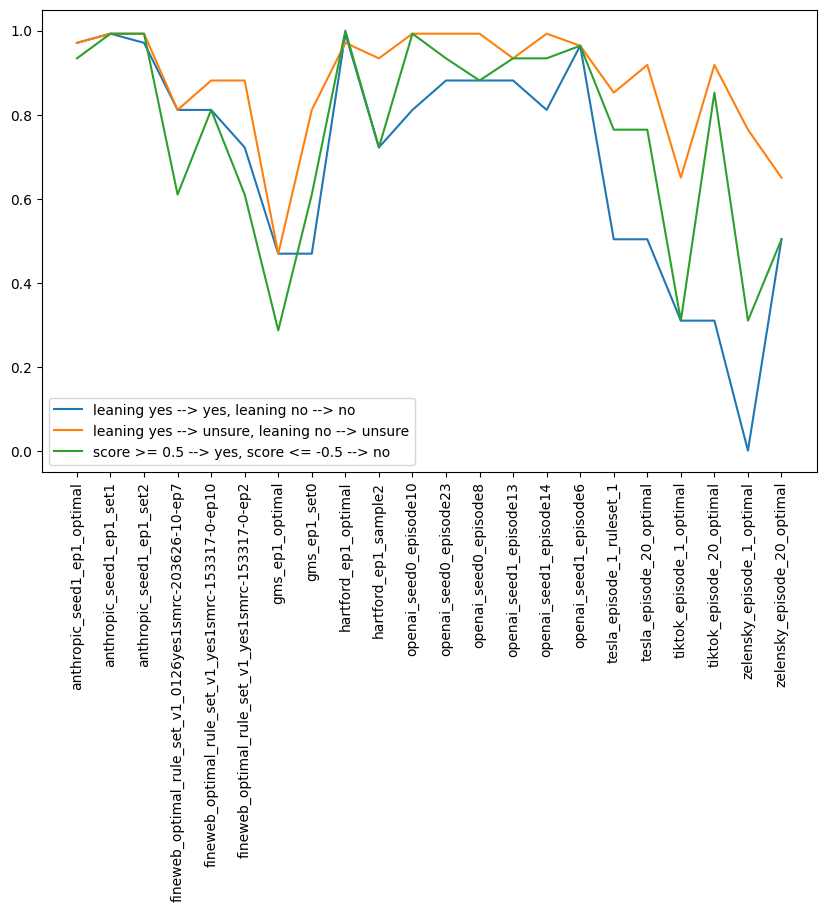

In [16]:
# plot the entropy column
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df_pivot_less_unsure["entropy"], label="leaning yes --> yes, leaning no --> no")
plt.plot(df_pivot_more_unsure["entropy"], label="leaning yes --> unsure, leaning no --> unsure")
plt.plot(df_pivot_score["entropy"], label="score >= 0.5 --> yes, score <= -0.5 --> no")

# rotate the x-axis labels
plt.xticks(rotation=90)

plt.legend()
plt.show()

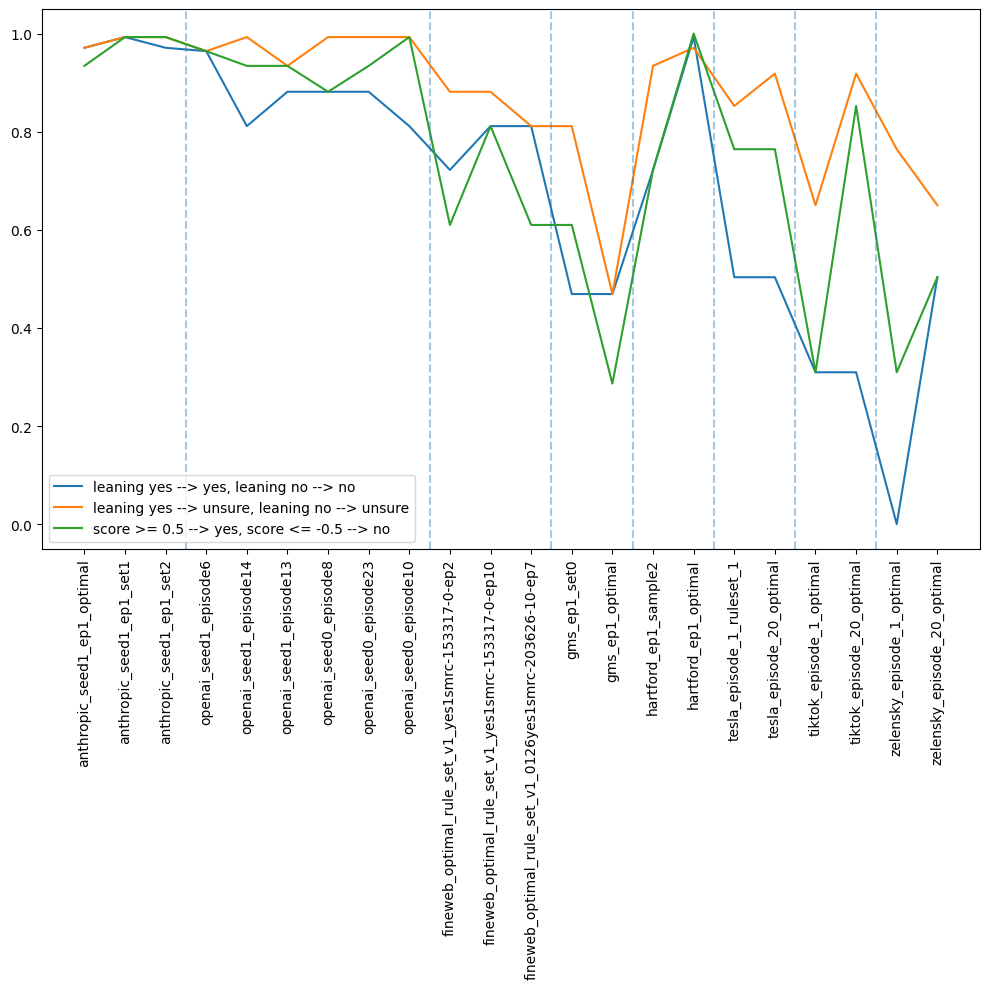

In [17]:
task_order = [
    "anthropic",
    "openai",
    "fineweb",
    "gms",
    "hartford",
    "tesla",
    "tiktok",
    "zelensky"
]

def reorder_df(_df):
    return (
        _df.assign(
            task=lambda d: d.index.str.split("_").str[0],
            task_rank=lambda d: d["task"].map({t: i for i, t in enumerate(task_order)})
        )
        .sort_values(["task_rank"])
    )

# use one dataframe to define the canonical ordering
df_ordered = reorder_df(df_pivot_less_unsure)
ordered_index = df_ordered.index

# reorder all dataframes consistently
df_pivot_less_unsure = reorder_df(df_pivot_less_unsure).loc[ordered_index]
df_pivot_more_unsure = reorder_df(df_pivot_more_unsure).loc[ordered_index]
df_pivot_score = reorder_df(df_pivot_score).loc[ordered_index]

# compute positions where task changes
task_series = df_ordered["task"]
boundary_positions = [
    i - 0.5
    for i in range(1, len(task_series))
    if task_series.iloc[i] != task_series.iloc[i - 1]
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(df_pivot_less_unsure["entropy"], label="leaning yes --> yes, leaning no --> no")
plt.plot(df_pivot_more_unsure["entropy"], label="leaning yes --> unsure, leaning no --> unsure")
plt.plot(df_pivot_score["entropy"], label="score >= 0.5 --> yes, score <= -0.5 --> no")

# add vertical separator lines between task groups
for pos in boundary_positions:
    plt.axvline(x=pos, linestyle="--", alpha=0.4)

plt.xticks(range(len(ordered_index)), ordered_index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()